# Evaluación y Testeo del Checkpoint - Unet++ (Clasificación de Tejidos)

Este notebook permite cargar un checkpoint entrenado, ejecutar inferencia en el conjunto de validación, computar las métricas clave e inspeccionar visualmente las predicciones generadas por el modelo.

### 1. Configurar Entorno y Añadir Rutas

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Encontrar la raíz del repositorio
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
print(f"Raíz del Repositorio: {REPO_ROOT}")

# Definir la ruta del modelo y añadirla al path para importar módulos locales
MODEL_DIR = os.path.join(REPO_ROOT, "src", "ClasificationAlgorithms", "Models", "Unet++")
sys.path.append(MODEL_DIR)
print(f"Ruta del Modelo: {MODEL_DIR}")

/home/diego-villalba/Proyecto_DFU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raíz del Repositorio: /home/diego-villalba/Proyecto_DFU
Ruta del Modelo: /home/diego-villalba/Proyecto_DFU/src/ClasificationAlgorithms/Models/Unet++


/home/diego-villalba/Proyecto_DFU/.venv/lib/python3.12/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.17). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


### 2. Importar Componentes Locales

In [2]:
from utils import get_loaders, load_checkpoint
from main import UnetPlusPlus
from metrics import check_metrics
model_name = "Unet++"
print("Módulos locales importados correctamente.")

Probando el modelo...


El modelo funciona correctamente.
(Time of 2 224x224 imgs:  0.51 s)


Módulos locales importados correctamente.


### 3. Cargar el Dataset de Validación

In [3]:
VAL_IMG_DIR = os.path.join(REPO_ROOT, "data", "dfu_tissue", "val_images")
VAL_MASK_DIR = os.path.join(REPO_ROOT, "data", "dfu_tissue", "val_masks")

val_transform = A.Compose([
    A.Resize(height=240, width=240),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2()
])

_, val_loader = get_loaders(
    VAL_IMG_DIR, VAL_MASK_DIR,
    VAL_IMG_DIR, VAL_MASK_DIR, # Usamos la de val para simplificar la carga
    batch_size=4, train_transform=val_transform, val_transform=val_transform,
    num_workers=0, pin_memory=True
)
print(f"Cargador de validación listo con {len(val_loader)} batches.")

Cargador de validación listo con 4 batches.


### 4. Cargar Checkpoint Guardado
Cargamos la arquitectura y cargamos los pesos guardados en la carpeta `output_assets_model/` del modelo.

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_class = UnetPlusPlus
model = model_class(in_channels=3, out_channels=4).to(DEVICE)

checkpoint_path = os.path.join(MODEL_DIR, "output_assets_model", "best_model_checkpoint_Unet++.pth")
if os.path.exists(checkpoint_path):
    print(f"Cargando checkpoint desde: {{checkpoint_path}}")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    load_checkpoint(checkpoint, model)
    print("Pesos cargados exitosamente.")
else:
    print(f"[-] No se encontró el checkpoint en {{checkpoint_path}}. Por favor ejecuta el entrenamiento primero.")

Cargando checkpoint desde: {checkpoint_path}
=> Loading checkpoint
Pesos cargados exitosamente.


### 5. Calcular Métricas de Evaluación en Validación

In [5]:
if os.path.exists(checkpoint_path):
    print("Evaluando métricas en el conjunto de validación...")
    metrics_res = check_metrics(val_loader, model, device=DEVICE)
    
    if isinstance(metrics_res, dict):
        # Formato de clasificación (diccionario de listas)
        for key, val in metrics_res.items():
            print(f"{key.capitalize()}: {val}")
    else:
        # Formato de segmentación (tupla)
        dice, iou, acc, prec, rec, f1 = metrics_res
        print(f"Dice Coefficient: {dice:.4f}")
        print(f"Intersection over Union (IoU): {iou:.4f}")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall: {rec:.4f}")
        print(f"F1 Score: {f1:.4f}")

Evaluando métricas en el conjunto de validación...


Classes:     [0, 1, 2, 3]
Acc:         ['0.8278', '0.9691', '0.9688', '0.8450']
Dice Coeff:  ['0.8914', '0.2504', '0.5068', '0.3884']
Dice_coefficient: [0.8914020657539368, 0.25040608644485474, 0.5067780017852783, 0.3883659243583679]
Iou: [0.8064448237419128, 0.15062758326530457, 0.3577706515789032, 0.24800992012023926]
Accuracy: [0.8277919292449951, 0.9691210985183716, 0.9687522053718567, 0.8450249433517456]
Precision: [0.9197300672531128, 0.2892040014266968, 0.5271782875061035, 0.33411404490470886]
Recall: [0.8684737682342529, 0.2228580266237259, 0.5054032802581787, 0.6648452281951904]
F1_score: [2.1907050609588623, 0.610578715801239, 1.1546728610992432, 1.1192704439163208]


### 6. Inspección Visual de Predicciones
Visualizamos algunas muestras al lado de su Ground Truth para evaluar de forma cualitativa.

[SUCCESS] Visualización de evaluación guardada en: /home/diego-villalba/Proyecto_DFU/src/ClasificationAlgorithms/Models/Unet++/output_assets_model/evaluation_samples.png


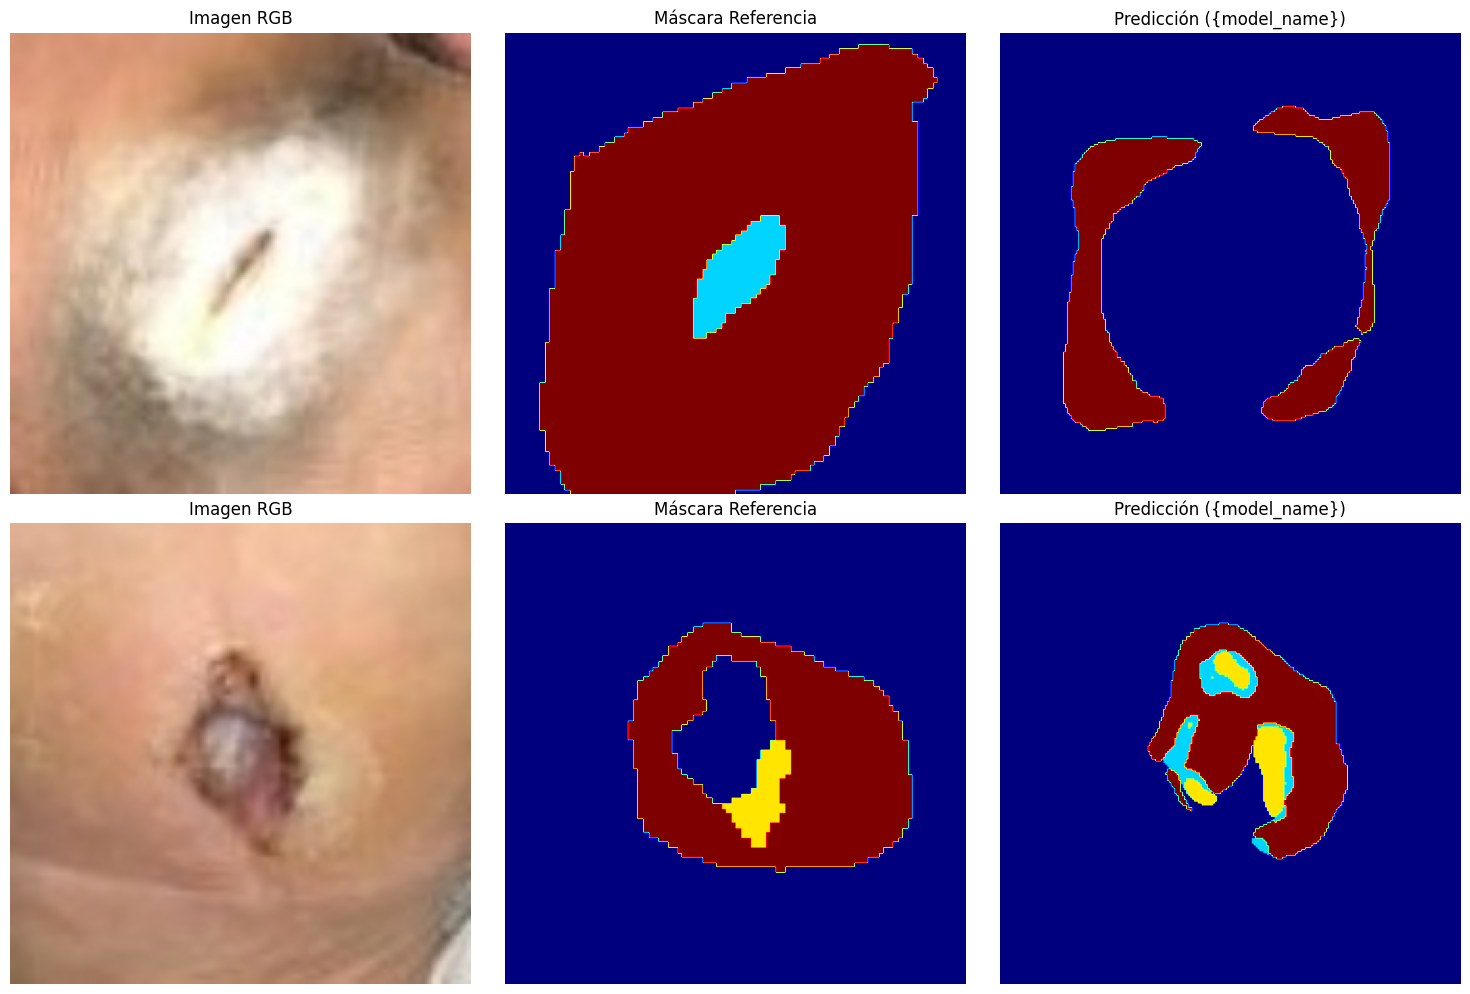

In [6]:
if os.path.exists(checkpoint_path):
    model.eval()
    images, masks = next(iter(val_loader))
    
    with torch.no_grad():
        preds = model(images.to(DEVICE))
        if True:
            preds = torch.softmax(preds, dim=1)
            preds = torch.argmax(preds, dim=1).cpu().numpy()
        else:
            preds = torch.sigmoid(preds)
            preds = (preds > 0.5).float().squeeze(1).cpu().numpy()
            
    images = images.permute(0, 2, 3, 1).numpy()
    masks = masks.numpy()
    
    # Dibujar muestras
    num_samples = min(2, len(images))
    fig, ax = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    for idx in range(num_samples):
        row = ax[idx] if num_samples > 1 else ax
        # Imagen de entrada
        row[0].imshow(images[idx])
        row[0].set_title("Imagen RGB")
        row[0].axis("off")
        
        # Ground Truth
        cmap = "gray" if masks[idx].max() <= 1 else "jet"
        row[1].imshow(masks[idx], cmap=cmap)
        row[1].set_title("Máscara Referencia")
        row[1].axis("off")
        
        # Inferencia Predicción
        row[2].imshow(preds[idx], cmap=cmap)
        row[2].set_title(f"Predicción ({{model_name}})")
        row[2].axis("off")
        
    # Guardar gráfico de validación visual
    save_path = os.path.join(MODEL_DIR, "output_assets_model", "evaluation_samples.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"[SUCCESS] Visualización de evaluación guardada en: {save_path}")
    plt.show()